In [1]:
import h5py
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("All libraries loaded!")

TensorFlow version: 2.21.0
All libraries loaded!


In [2]:
import h5py
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

EQ_HDF5     = r'chunk2\chunk2.hdf5'
EQ_CSV      = r'chunk2\chunk2.csv'
WAVE_LENGTH = 6000    # full 60-second waveform
N_SAMPLES   = 2000

def load_stead_regression(hdf5_path, csv_path, n_samples):
    """
    Load earthquake waveforms with magnitude as the label.
    Regression task — predict a number, not 0/1.
    """
    df = pd.read_csv(csv_path, low_memory=False)

    # Need both P-arrival AND magnitude to be present
    df = df[
        df['p_arrival_sample'].notna() &
        df['source_magnitude'].notna()
    ].reset_index(drop=True)

    print(f"Valid records: {len(df)}")
    print(f"Magnitude range: {df['source_magnitude'].min():.1f}"
          f" to {df['source_magnitude'].max():.1f}")
    print(f"Magnitude mean : {df['source_magnitude'].mean():.2f}")

    df = df.sample(n=min(n_samples, len(df)), random_state=42)

    X, y = [], []

    with h5py.File(hdf5_path, 'r') as f:
        for _, row in df.iterrows():
            try:
                trace_name = row['trace_name']
                magnitude  = float(row['source_magnitude'])

                waveform = f['data'][trace_name][:]   # (6000, 3)

                # Use vertical channel only — same as classification model
                channel = waveform[:, 2].astype(np.float32)

                # Normalize
                std = np.std(channel)
                if std > 0:
                    channel = channel / std

                X.append(channel)
                y.append(magnitude)

            except Exception:
                continue

    X = np.array(X)[..., np.newaxis]   # shape: (N, 6000, 1)
    y = np.array(y)                     # shape: (N,) — magnitude values

    print(f"\nLoaded       : {len(X)} samples")
    print(f"Input shape  : {X.shape}")
    print(f"Label shape  : {y.shape}")
    print(f"Label example: {y[:5]}")   # should be magnitude numbers

    return X, y

X, y = load_stead_regression(EQ_HDF5, EQ_CSV, N_SAMPLES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Valid records: 200000
Magnitude range: -0.1 to 6.5
Magnitude mean : 1.33

Loaded       : 2000 samples
Input shape  : (2000, 6000, 1)
Label shape  : (2000,)
Label example: [0.01 4.4  1.03 2.04 3.7 ]

Train: 1600, Test: 400


In [3]:
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Input shape      : {X_train.shape}")

Training samples : 1600
Test samples     : 400
Input shape      : (1600, 6000, 1)


In [4]:
tf.random.set_seed(42)
np.random.seed(42)

model = models.Sequential([

    # CNN PART — same layers as before
    layers.Conv1D(32, kernel_size=5, activation='relu',
                  input_shape=(6000, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=4),

    # NEW — LSTM reads CNN output as a time sequence
    # After pooling the sequence length is short enough for LSTM
    # return_sequences=False — only output at the final timestep
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),

    # OUTPUT — same as regression CNN
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.summary()

C:\Users\rajiv\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 5996, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 5996, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1499, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1497, 64)            │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1497, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 374, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 372, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 93, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,009 (324.25 KB)

 Trainable params: 82,817 (323.50 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='mean_absolute_error',   # MAE — not binary crossentropy
    metrics=['mae']
)

print("Model compiled for REGRESSION")
print("Output: earthquake magnitude (a number)")
print("Loss: MAE — how many magnitude units off on average")

Model compiled for REGRESSION
Output: earthquake magnitude (a number)
Loss: MAE — how many magnitude units off on average


In [6]:
# Learning rate scheduler — slows down when model stops improving
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,        # 64 for faster training on CPU
    validation_split=0.1,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 735ms/step - loss: 0.5726 - mae: 0.5726 - val_loss: 1.1733 - val_mae: 1.1733 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 433ms/step - loss: 0.4499 - mae: 0.4499 - val_loss: 1.0044 - val_mae: 1.0044 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 388ms/step - loss: 0.4228 - mae: 0.4228 - val_loss: 0.9796 - val_mae: 0.9796 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step - loss: 0.4312 - mae: 0.4312 - val_loss: 0.8558 - val_mae: 0.8558 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step - loss: 0.4064 - mae: 0.4064 - val_loss: 0.7790 - val_mae: 0.7790 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 480ms/step - loss: 0.4101 - mae: 0.4101 - val_loss: 0.7370 - val_mae: 0.7370 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 431ms/step - loss: 0.3953 - mae: 0.3953 - val_loss: 0.7875 - val_mae: 0.7875 - learning_rate: 0.0010
Ep

In [7]:
y_pred = model.predict(X_test).flatten()

mae  = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("=== Regression Results — Magnitude Prediction ===")
print(f"MAE  : {mae:.4f} magnitude units")
print(f"RMSE : {rmse:.4f} magnitude units")

# Show 10 example predictions
print(f"\n{'Actual':>10}  {'Predicted':>10}  {'Error':>10}")
print("-" * 38)
for i in range(10):
    actual = y_test[i]
    pred   = y_pred[i]
    error  = abs(actual - pred)
    print(f"{actual:>10.2f}  {pred:>10.2f}  {error:>10.2f}")

# Distribution of errors
print(f"\nErrors within 0.5 magnitude: "
      f"{np.mean(np.abs(y_test-y_pred) < 0.5)*100:.1f}%")
print(f"Errors within 1.0 magnitude: "
      f"{np.mean(np.abs(y_test-y_pred) < 1.0)*100:.1f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
=== Regression Results — Magnitude Prediction ===
MAE  : 0.2685 magnitude units
RMSE : 0.4087 magnitude units

    Actual   Predicted       Error
--------------------------------------
      0.80        1.09        0.29
      1.22        1.10        0.12
      0.79        0.70        0.09
      1.32        0.83        0.49
      0.34        0.35        0.01
      1.30        1.05        0.25
      0.92        1.40        0.48
      1.03        0.87        0.16
      1.62        2.23        0.61
      0.88        0.62        0.26

Errors within 0.5 magnitude: 85.5%
Errors within 1.0 magnitude: 96.8%


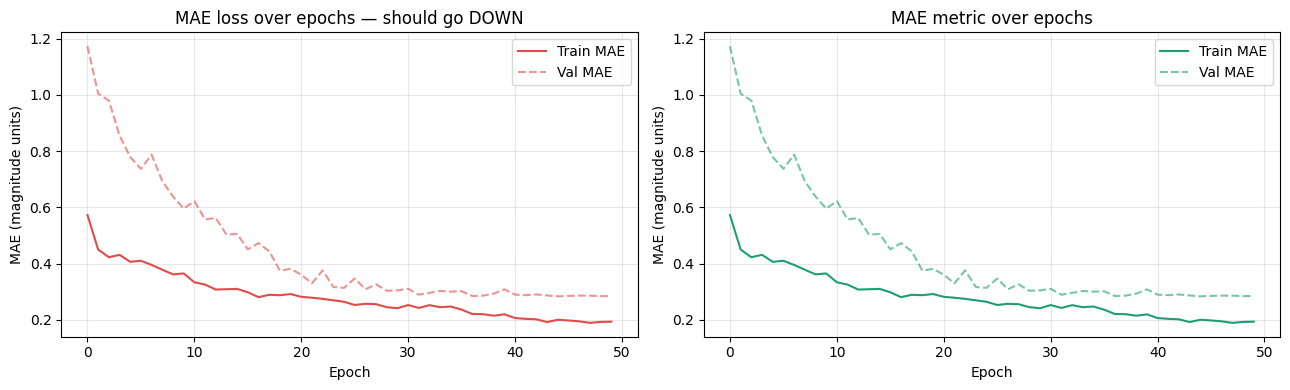

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],
         label='Train MAE', color='#E24B4A')
ax1.plot(history.history['val_loss'],
         label='Val MAE',   color='#E24B4A', linestyle='--', alpha=0.6)
ax1.set_title('MAE loss over epochs — should go DOWN')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MAE (magnitude units)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'],
         label='Train MAE', color='#1D9E75')
ax2.plot(history.history['val_mae'],
         label='Val MAE',   color='#1D9E75', linestyle='--', alpha=0.6)
ax2.set_title('MAE metric over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE (magnitude units)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()